# Titanic Data

### STEP 01. 실행 환경 확인

In [67]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Current working directory:", Path.cwd())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python executable: c:\dev\llm-data-analysis-course\.venv\Scripts\python.exe
Python version: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
Current working directory: c:\dev\llm-data-analysis-course\notebooks
pandas: 3.0.5
numpy: 2.5.3


실행 환경 확인 : 기본 패키지 확인 등

현재 Python: c:\dev\llm-data-analysis-course\.venv\Scripts\python.exe

현재 Notebook Kernel: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]

현재 작업 폴더: c:\dev\llm-data-analysis-course\notebooks

확인한 패키지: pandas, numpy

환경에서 추가로 확인할 점:

### STEP 02. Titanic 데이터 확보와 로딩
프로젝트 루트 찾기

In [68]:
from pathlib import Path

def get_project_root(start_path: Path | None = None) -> Path:
    """현재 위치에서 상위 폴더를 탐색해 data 폴더가 있는 프로젝트 루트를 찾는다."""
    current = (start_path or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "data").is_dir():
            return path
    raise FileNotFoundError("data 폴더가 있는 프로젝트 루트를 찾을 수 없습니다.")

project_root = get_project_root()
data_path = project_root / "data" / "titanic" / "train.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Titanic 데이터가 없습니다: {data_path}\n"
        "저장소 루트에서 python scripts/prepare_titanic_data.py 를 먼저 실행하세요."
    )

print("project_root :", project_root)
print("data_path :", data_path)

project_root : C:\dev\llm-data-analysis-course
data_path : C:\dev\llm-data-analysis-course\data\titanic\train.csv


프로젝트 루트 확인

02_2 데이터 로딩

In [69]:
import pandas as pd

df = pd.read_csv(data_path)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

print("data path:", data_path)
print("shape:", df.shape)
print("columns:", df.columns.tolist())

print(df.head())

data path: C:\dev\llm-data-analysis-course\data\titanic\train.csv
shape: (891, 12)
columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
   PassengerId  Survived  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                              Heikkinen, Miss Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5       

DataFrame 확인

### STEP 03. 데이터 구조와 품질의 첫인상 확인
03_1 크기와 앞부분 확인

In [70]:
print("shape:", df.shape)

print(df.head())

shape: (891, 12)
   PassengerId  Survived  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                              Heikkinen, Miss Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                           Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S


03_2 dtype과 기본 구조 확인

In [71]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


어떤 컬럼이 숫자형인가? PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare

어떤 컬럼이 문자열인가? Name, Sex, Ticket, Cabin, Embarked

숫자로 저장되어 있지만 실제 의미는 범주형인 컬럼이 있는가? Survived, Pclass

결측치가 보이는가? Age, Cabin, Embarked

02_3. 결측치 요약

In [72]:
missing_count = df.isna().sum()
missing_rate = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate_pct": missing_rate,
}).sort_values("missing_count", ascending=False)

print(missing_summary)

             missing_count  missing_rate_pct
Cabin                  687             77.10
Age                    177             19.87
Embarked                 2              0.22
PassengerId              0              0.00
Name                     0              0.00
Pclass                   0              0.00
Survived                 0              0.00
Sex                      0              0.00
Parch                    0              0.00
SibSp                    0              0.00
Fare                     0              0.00
Ticket                   0              0.00


02_4. 중복과 기초 통계

In [73]:
print("duplicate rows:", df.duplicated().sum())

print(df.describe(include="all"))

duplicate rows: 0
        PassengerId    Survived      Pclass                     Name   Sex         Age       SibSp       Parch  Ticket        Fare Cabin Embarked
count    891.000000  891.000000  891.000000                      891   891  714.000000  891.000000  891.000000     891  891.000000   204      889
unique          NaN         NaN         NaN                      891     2         NaN         NaN         NaN     681         NaN   147        3
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male         NaN         NaN         NaN  347082         NaN    G6        S
freq            NaN         NaN         NaN                        1   577         NaN         NaN         NaN       7         NaN     4      644
mean     446.000000    0.383838    2.308642                      NaN   NaN   29.699118    0.523008    0.381594     NaN   32.204208   NaN      NaN
std      257.353842    0.486592    0.836071                      NaN   NaN   14.526497    1.102743    0.80

- PassengerId 중복 여부
- Age 범위
- Fare 이상치
- 각 범주형 컬럼의 unique 개수
- Sex / Embarked / Pclass의 값 분포

In [74]:
print(df["Embarked"].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


현재 STEP 03 실행 결과를 기준으로

추가로 확인할 가치가 있는 데이터 품질 분석 후보 3개를 제안해 주세요.

각 후보에 대해
1. 무엇을 확인하는지
2. 왜 필요한지
3. 결과에 따라 다음 판단이 어떻게 달라지는지

를 설명해 주세요.

아직 코드는 작성하지 마세요.

### STEP 04. 분석 문제와 Target 정의

Target 확인

In [75]:
print("Survived missing:", df["Survived"].isna().sum())
print("Survived unique:", sorted(df["Survived"].dropna().unique()))
print("\nClass count")
print(df["Survived"].value_counts().sort_index())
print("\nClass ratio")
print(df["Survived"].value_counts(normalize=True).sort_index())

Survived missing: 0
Survived unique: [np.int64(0), np.int64(1)]

Class count
Survived
0    549
1    342
Name: count, dtype: int64

Class ratio
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Survived가 0과 1 두 범주이므로 이번 문제는 기본적으로 이진 분류(Binary Classification) 문제입니다.

#### 04_2. Feature와 Target

Feature = 예측에 사용할 입력 정보

Target  = 맞히고 싶은 정답

예를 들어 Sex, Pclass, Age, Fare 등은 Feature 후보가 될 수 있고 Survived는 Target입니다.

### STEP 05. 결측치 처리

In [76]:
df_work = df.copy()

In [77]:
missing_summary = pd.DataFrame({
    "count": df_work.isna().sum(),
    "rate_pct": (df_work.isna().mean() * 100).round(2),
}).sort_values("count", ascending=False)

missing_summary

,count,rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [78]:
age_median = df_work["Age"].median()
embarked_mode = df_work["Embarked"].mode().iloc[0]
df_work["Age"] = df_work["Age"].fillna(age_median)
df_work["Embarked"] = df_work["Embarked"].fillna(embarked_mode)

In [79]:
df_work[["Age", "Embarked", "Cabin"]].isna().sum()

Age           0
Embarked      0
Cabin       687
dtype: int64

### STEP 07. 범주형 데이터 변환 원리 이해

07_1. 범주형 값 확인

In [80]:
for col in ["Sex", "Embarked", "Pclass"]:
    print(f"\n[{col}]")
    print(df_work[col].value_counts(dropna=False))


[Sex]
Sex
male      577
female    314
Name: count, dtype: int64

[Embarked]
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

[Pclass]
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


07_2. 교육용 인코딩 branch

In [81]:
df_encoded = df_work.copy()

Mapping 예시

In [82]:
df_encoded["SexMapped"] = df_encoded["Sex"].map({
    "male": 0,
    "female": 1,
})

df_encoded[["Sex", "SexMapped"]].head()

,Sex,SexMapped
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


One-Hot Encoding 예시

In [83]:
embarked_dummies = pd.get_dummies(
    df_encoded["Embarked"],
    prefix="Embarked",
    dtype=int,
)

embarked_dummies.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [84]:
result_df = pd.concat([df_encoded[["Embarked"]], embarked_dummies], axis=1)

### STEP 08. 시각화와 기본 패턴 확인

질문 1. 전체 생존/비생존 인원은 어떻게 분포하는가?

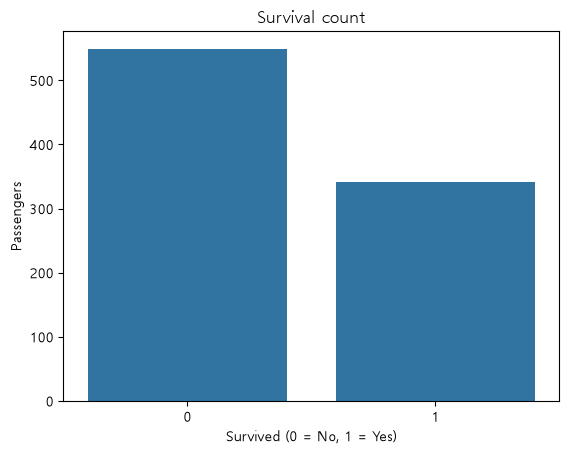

In [85]:
import matplotlib.pyplot as plt

import seaborn as sns

sns.countplot(data=df_work, x="Survived")

plt.title("Survival count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passengers")

plt.show()

관찰: 전체 승객 중 500명 이상이 사망했고, 300명 이상이 생존했다

해석: 사망자에 비해 생존자가 적다

추가 확인: 정확한 숫자에 대해 확인이 필요하고, 그것을 Chart 위에 표현하면 더 좋을 것 같다

질문 2. 성별에 따라 생존율이 다른가?

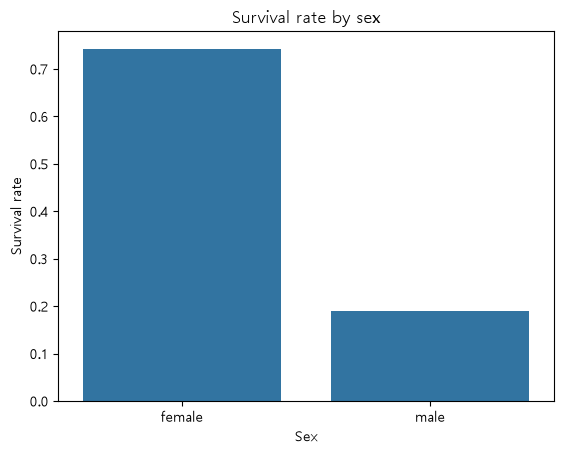

In [86]:

sex_survival = (
    df_work.groupby("Sex", as_index=False)["Survived"]
    .mean()
)

sns.barplot(data=sex_survival, x="Sex", y="Survived")
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")

plt.show()

질문 3. 객실 등급에 따라 생존율이 다른가?

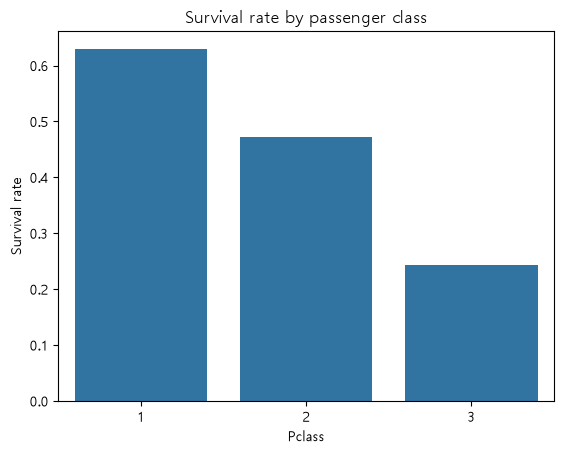

In [87]:

pclass_survival = (
    df_work.groupby("Pclass", as_index=False)["Survived"]
    .mean()
)

sns.barplot(data=pclass_survival, x="Pclass", y="Survived")
plt.title("Survival rate by passenger class")
plt.ylabel("Survival rate")

plt.show()

질문 4. 나이와 생존 사이에 어떤 패턴이 보이는가?

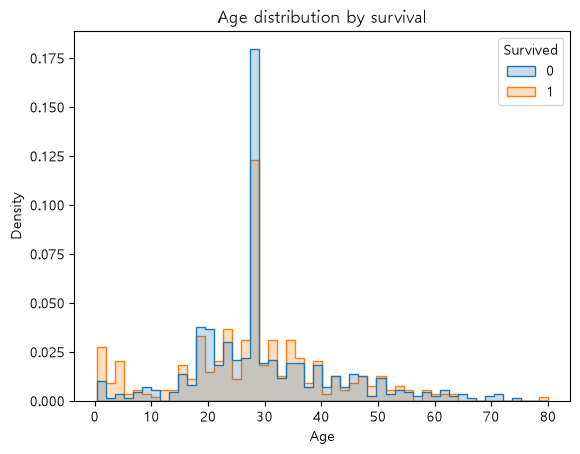

In [88]:
sns.histplot(
    data=df_work,
    x="Age",
    hue="Survived",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
)

plt.title("Age distribution by survival")

plt.show()

질문 5. Fare와 생존 사이에 어떤 패턴이 보이는가?

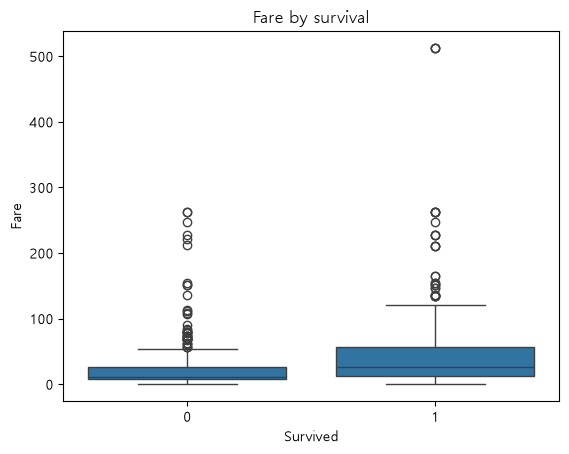

In [89]:
sns.boxplot(data=df_work, x="Survived", y="Fare")

plt.title("Fare by survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

### ★ 개인 판단 지점 5

기본 그래프를 확인한 뒤 학생이 추가 시각화 하나를 직접 선택합니다.

AI Prompt 예시

현재 STEP 08에서 실제로 확인한 그래프 결과를 기준으로 추가로 확인할 가치가 있는 시각화 후보 3개를 제안해 주세요.

각 후보에 대해

1. 확인하려는 질문
2. 사용할 변수
3. 어떤 결과가 나오면 의미가 있는지
4. 난이도

를 설명해 주세요.

아직 코드는 작성하지 마세요.

현재 STEP 08에서 확인한 전체 생존 인원 분포 및 성별 생존율 관점에 이어, 타이타닉 데이터의 숨겨진 패턴과 변수 간의 관계를 입체적으로 파악하기 위해 추가로 확인할 가치가 있는 시각화 후보 3가지를 제안해 드립니다. (아직 코드는 작성하지 않았습니다.)

1. 객실 등급(Pclass)별 생존율 비교 (그룹별 막대 그래프)
확인하려는 질문: 객실 등급(1·2·3등석)에 따라 생존율에 구조적인 차이가 존재하는가?

사용할 변수: Pclass, Survived

의미 있는 결과: 1등석 승객의 생존율이 3등석 승객에 비해 압도적으로 높고, 등급이 낮아질수록 생존율이 계단식으로 뚜렷하게 감소하는 패턴이 나타날 때 (사회경제적 지위가 생존에 미친 결정적 영향 입증).

난이도: 낮음

2. 연령(Age) 분포에 따른 생존 여부 비교 (KDE Plot 또는 밀도 히스토그램)
확인하려는 질문: 승객의 나이에 따라 생존자와 사망자의 연령대 분포가 어떻게 갈리는가? ("여성과 어린이 우선 구조" 원칙이 실제 데이터에 반영되었는가?)

사용할 변수: Age, Survived

의미 있는 결과: 0~10세 이하의 저연령층 구간에서 생존자 비율(밀도)이 사망자보다 현저히 높고, 특정 청장년층 구간에서 사망자 밀도가 집중적으로 높게 나타나는 분포적 특징이 확인될 때.

난이도: 보통

3. 운임 요금(Fare)과 객실 등급(Pclass)에 따른 생존 여부 (박스플롯 또는 바이올린 플롯)
확인하려는 질문: 지불한 운임 요금의 크기가 생존 여부에 미치는 영향은 무엇이며, 객실 등급별 요금 편차와 어떻게 상호작용하는가?

사용할 변수: Fare, Pclass, Survived

의미 있는 결과: 동일한 객실 등급 안에서도 생존한 승객들의 평균 지불 요금이 비생존자보다 높거나, 고액 요금을 지불한 승객군에서 생존율이 확연히 높게 나타나는 세부 패턴이 발견될 때.

난이도: 보통 ~ 약간 높음

제안드린 3가지 시각화 후보 중 다음 단계에서 가장 먼저 코드로 구현해보고 싶으신 주제가 있으신가요?

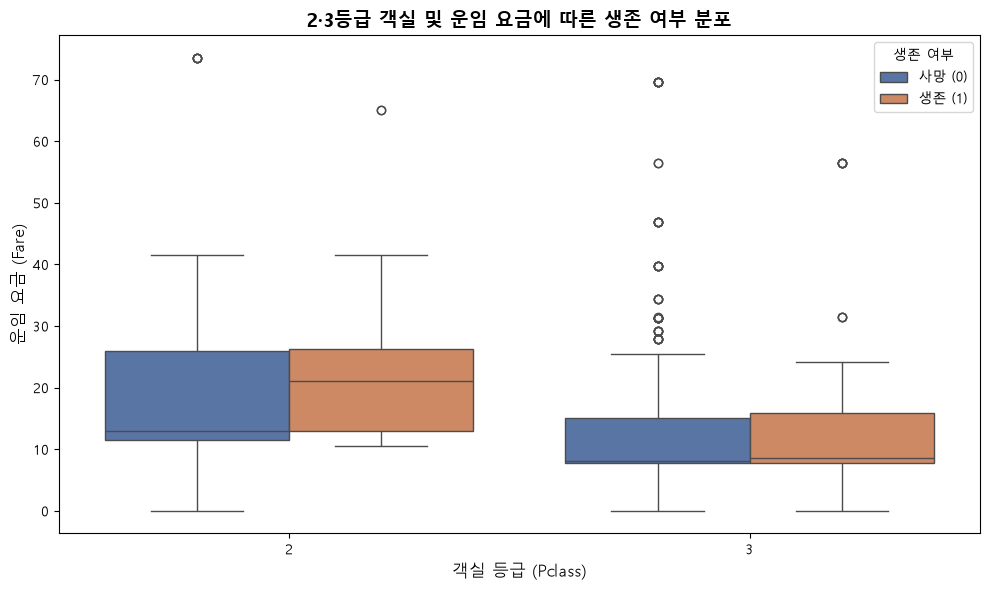

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.font_manager as fm
import os

# 1. 운영체제에 맞는 폰트 설정 및 캐시 꼬임 방지
if platform.system() == 'Windows':
    font_family = 'Malgun Gothic'
    font_path = "C:/Windows/Fonts/malgun.ttf"
    if os.path.exists(font_path):
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
    else:
        plt.rc('font', family=font_family)
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

# 마이너스 부호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 타이타닉 데이터셋 불러오기
titanic = sns.load_dataset('titanic')

# 2등급(2)과 3등급(3) 승객만 필터링
titanic_filtered = titanic[titanic['pclass'].isin([2, 3])]

# 캔버스 크기 설정
plt.figure(figsize=(10, 6))

# [수정] 색상이 명확히 구분되도록 커스텀 컬러 팔레트 지정 (사망: 파랑 계열, 생존: 주황/코랄 계열)
distinct_palette = ['#4c72b0', '#dd8452']

# 박스플롯 생성
ax = sns.boxplot(
    x='pclass',
    y='fare',
    hue='survived',
    data=titanic_filtered,
    palette=distinct_palette
)

# 그래프 제목 및 라벨 설정
plt.title('2·3등급 객실 및 운임 요금에 따른 생존 여부 분포', fontsize=14, fontweight='bold')
plt.xlabel('객실 등급 (Pclass)', fontsize=12)
plt.ylabel('운임 요금 (Fare)', fontsize=12)

# 범례 설정 (명시적으로 라벨 지정)
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='생존 여부', labels=['사망 (0)', '생존 (1)'])

# 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

In [91]:
# 2·3등급 데이터에서 등급(pclass)과 생존여부(survived)별 요금 통계 집계
summary_table = titanic_filtered.groupby(['pclass', 'survived'])['fare'].agg(
    Count='count',
    Mean_Fare='mean',
    Median_Fare='median',
    Min_Fare='min',
    Max_Fare='max'
).reset_index()

# 표 출력
display(summary_table) # 주피터 노트북 환경인 경우 display() 사용

,pclass,survived,Count,Mean_Fare,Median_Fare,Min_Fare,Max_Fare
0,2,0,97,19.412328,13.0000,0.0,73.5000
1,2,1,87,22.055700,21.0000,10.5,65.0000
2,3,0,372,13.669364,8.0500,0.0,69.5500
3,3,1,119,13.694887,8.5167,0.0,56.4958


### STEP 10. Feature 설계

In [92]:
feature_demo = df_work.copy()

feature_demo["FamilySize"] = feature_demo["SibSp"] + feature_demo["Parch"] + 1

feature_demo["IsAlone"] = (feature_demo["FamilySize"] == 1).astype(int)

display(feature_demo[["SibSp", "Parch", "FamilySize", "IsAlone", "Survived"]].head())

,SibSp,Parch,FamilySize,IsAlone,Survived
0,1,0,2,0,0
1,1,0,2,0,1
2,0,0,1,1,1
3,1,0,2,0,1
4,0,0,1,1,0


### STEP 11. 학습/테스트 데이터 준비

In [93]:
model_source = df.copy()

model_source["FamilySize"] = (
    model_source["SibSp"] + model_source["Parch"] + 1
)

model_source["IsAlone"] = (
    model_source["FamilySize"] == 1
).astype(int)

In [94]:
raw_input_columns = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"
]
feature_columns = raw_input_columns + ["FamilySize", "IsAlone"]

numeric_features = [
    "Age", "SibSp", "Parch", "Fare", "FamilySize"
]

categorical_features = [
    "Pclass", "Sex", "Embarked", "IsAlone"
]

In [95]:
X = model_source[feature_columns].copy()

y = model_source["Survived"].astype(int).copy()

학습용/테스트용 데이터로 분리

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

### STEP 12. 전처리를 하나씩 직접 실행하기

STEP 12-1. 숫자형 결측치 처리

In [97]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy="median")

X_train_num_imputed = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)

X_test_num_imputed = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index,
)

STEP 12-2. 범주형 결측치 처리

In [98]:
categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_cat_imputed = pd.DataFrame(
    categorical_imputer.fit_transform(X_train[categorical_features]),
    columns=categorical_features,
    index=X_train.index,
)

X_test_cat_imputed = pd.DataFrame(
    categorical_imputer.transform(X_test[categorical_features]),
    columns=categorical_features,
    index=X_test.index,
)

STEP 12-3. One-Hot Encoding

In [99]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

X_train_cat_encoded_array = encoder.fit_transform(X_train_cat_imputed)
X_test_cat_encoded_array = encoder.transform(X_test_cat_imputed)
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded_array,
    columns=encoded_feature_names,
    index=X_train.index,
)

X_test_cat_encoded = pd.DataFrame(
    X_test_cat_encoded_array,
    columns=encoded_feature_names,
    index=X_test.index,
)

STEP 12-4. 정규화와 표준화 구분

In [100]:
from sklearn.preprocessing import MinMaxScaler

minmax_demo = MinMaxScaler()

minmax_preview = pd.DataFrame(
    minmax_demo.fit_transform(
        X_train_num_imputed[["Age", "Fare"]]
    ),
    columns=["Age_minmax", "Fare_minmax"],
    index=X_train.index,
)

display(minmax_preview.head())

,Age_minmax,Fare_minmax
692,0.352852,0.110272
481,0.352852,0.000000
527,0.352852,0.432884
855,0.220910,0.018250
801,0.384267,0.051237


STEP 12-5. StandardScaler로 실제 표준화

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num_imputed),
    columns=numeric_features,
    index=X_train.index,
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num_imputed),
    columns=numeric_features,
    index=X_test.index,
)

STEP 12-6. 숫자형과 범주형 데이터 결합

In [102]:
X_train_ready = pd.concat(
    [X_train_num_scaled, X_train_cat_encoded],
    axis=1,
)

X_test_ready = pd.concat(
    [X_test_num_scaled, X_test_cat_encoded],
    axis=1,
)

STEP 12-7. Logistic Regression Baseline 학습

In [ ]:
from sklearn import set_config
from sklearn.linear_model import LogisticRegression

set_config(display="text")

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

baseline_model.fit(X_train_ready, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### STEP 13. 성능 평가와 Confusion Matrix

In [106]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

baseline_pred = baseline_model.predict(X_test_ready)

print("accuracy :", round(accuracy_score(y_test, baseline_pred), 4))
print("precision:", round(precision_score(y_test, baseline_pred), 4))
print("recall   :", round(recall_score(y_test, baseline_pred), 4))
print("f1       :", round(f1_score(y_test, baseline_pred), 4))

accuracy : 0.8156
precision: 0.8103
recall   : 0.6812
f1       : 0.7402


In [107]:
cm = confusion_matrix(y_test, baseline_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(cm)
print({"TN": tn, "FP": fp, "FN": fn, "TP": tp})

[[99 11]
 [22 47]]
{'TN': np.int64(99), 'FP': np.int64(11), 'FN': np.int64(22), 'TP': np.int64(47)}


In [108]:
from sklearn.ensemble import RandomForestClassifier

additional_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

additional_model.fit(X_train_ready, y_train)
additional_pred = additional_model.predict(X_test_ready)

In [109]:
model_compare = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, baseline_pred),
        "f1": f1_score(y_test, baseline_pred),
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, additional_pred),
        "f1": f1_score(y_test, additional_pred),
    },
])

display(model_compare)

,model,accuracy,f1
0,Logistic Regression,0.815642,0.740157
1,Random Forest,0.810056,0.725806


In [111]:
FINAL_MODEL_CHOICE = "baseline"

if FINAL_MODEL_CHOICE == "baseline":

    final_model = baseline_model

    final_model_name = "Logistic Regression"

elif FINAL_MODEL_CHOICE == "random_forest":

    final_model = additional_model

    final_model_name = "Random Forest"

else:

    raise ValueError("baseline 또는 random_forest를 선택하세요.")

In [112]:
import json

import joblib

models_dir = project_root / "models"

models_dir.mkdir(parents=True, exist_ok=True)

bundle_path = models_dir / "titanic_model_bundle.joblib"

contract_path = models_dir / "titanic_model_contract.json"

model_bundle = {

    "numeric_imputer": numeric_imputer,

    "categorical_imputer": categorical_imputer,

    "encoder": encoder,

    "scaler": scaler,

    "model": final_model,

}

joblib.dump(model_bundle, bundle_path)

['C:\\dev\\llm-data-analysis-course\\models\\titanic_model_bundle.joblib']

In [113]:

model_contract = {

    "task": "binary_classification",

    "target": "Survived",

    "positive_class": 1,

    "raw_input_columns": raw_input_columns,

    "model_feature_columns": feature_columns,

    "numeric_features": numeric_features,

    "categorical_features": categorical_features,

    "prepared_feature_columns": X_train_ready.columns.tolist(),

    "derived_features": ["FamilySize", "IsAlone"],

    "scaling": "StandardScaler",

    "final_estimator": type(final_model).__name__,

}

In [115]:
import json
from pathlib import Path

project_root = Path.cwd()

# Notebook을 notebooks 폴더에서 실행하는 경우
if project_root.name == "notebooks":
    project_root = project_root.parent

contract_path = project_root / "models" / "titanic_model_contract.json"

contract_path.parent.mkdir(parents=True, exist_ok=True)

contract_path.write_text(
    json.dumps(
        model_contract,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print("Contract 저장 완료:")
print(contract_path.resolve())
print("파일 존재:", contract_path.exists())

Contract 저장 완료:
C:\dev\llm-data-analysis-course\models\titanic_model_contract.json
파일 존재: True
